In [2]:
import pandas as pd
df = pd.read_csv("http://114.207.245.181:13000/csv/time01.csv")
df

,time,price,amount
0,2024-04-01 00:00:00,99,9
1,2024-04-01 00:02:00,91,18
2,2024-04-01 00:04:00,92,18
3,2024-04-01 00:06:00,38,5
4,2024-04-01 00:08:00,29,11
...,...,...,...
95,2024-04-01 03:10:00,70,16
96,2024-04-01 03:12:00,53,10
97,2024-04-01 03:14:00,50,14
98,2024-04-01 03:16:00,23,17


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   time    100 non-null    object
 1   price   100 non-null    int64 
 2   amount  100 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 2.5+ KB


In [4]:
df.dtypes

time      object
price      int64
amount     int64
dtype: object

In [5]:
df['time'] = pd.to_datetime(df['time'])
df.dtypes

time      datetime64[ns]
price              int64
amount             int64
dtype: object

In [6]:
# time을 인덱스로 변환
df.set_index('time', inplace=True)

In [7]:
df.resample('5min')[['price', 'amount']].sum()

,price,amount
time,,
2024-04-01 00:00:00,282,45
2024-04-01 00:05:00,67,16
2024-04-01 00:10:00,196,45
2024-04-01 00:15:00,90,26
2024-04-01 00:20:00,164,42
2024-04-01 00:25:00,130,7
2024-04-01 00:30:00,122,25
2024-04-01 00:35:00,104,13
2024-04-01 00:40:00,208,27


In [8]:
df2 = df.resample('5min')[['price', 'amount']].agg(['sum', 'min', 'max'])
df2

price         amount        
                      sum min max    sum min max
time                                            
2024-04-01 00:00:00   282  91  99     45   9  18
2024-04-01 00:05:00    67  29  38     16   5  11
2024-04-01 00:10:00   196  21  93     45   9  18
2024-04-01 00:15:00    90  28  62     26   7  19
2024-04-01 00:20:00   164  22  75     42  11  16
2024-04-01 00:25:00   130  50  80      7   2   5
2024-04-01 00:30:00   122  15  82     25   5  13
2024-04-01 00:35:00   104  39  65     13   3  10
2024-04-01 00:40:00   208  29  91     27   3  13
2024-04-01 00:45:00   104  48  56     10   4   6
2024-04-01 00:50:00   128  26  60     44  12  17
2024-04-01 00:55:00   131  63  68     27  13  14
2024-04-01 01:00:00   125  20  64     28   2  19
2024-04-01 01:05:00    85  41  44     18   7  11
2024-04-01 01:10:00   176  20  90     42   9  18
2024-04-01 01:15:00   155  74  81     31  14  17
2024-04-01 01:20:00   104  13  60     21   1  19
2024-04-01 01:25:00   109  53  56     33  14  19
2024-04-01 01:30:00    78  11  43     38   8  18
2024-04-01 01:35:00    90  33  57     22   7  15
2024-04-01 01:40:00   200  40  94     22   1  12
2024-04-01 01:45:00   131  44  87     21   4  17
2024-04-01 01:50:00   150  18  81     14   3   6
2024-04-01 01:55:00   180  89  91      7   3   4
2024-04-01 02:00:00   188  50  71     28   5  14
2024-04-01 02:05:00   135  48  87     29  13  16
2024-04-01 02:10:00   104  24  55     27   5  16
2024-04-01 02:15:00   123  50  73      4   1   3
2024-04-01 02:20:00   143  18  65     31   5  19
2024-04-01 02:25:00   129  30  99     15   2  13
2024-04-01 02:30:00   105  18  45     32   1  18
2024-04-01 02:35:00   142  53  89     25  10  15
2024-04-01 02:40:00   172  40  90     17   4   9
2024-04-01 02:45:00    95  31  64     24   6  18
2024-04-01 02:50:00   211  38  92     41  11  15
2024-04-01 02:55:00   110  17  93     18   2  16
2024-04-01 03:00:00    91  20  44     26   1  18
2024-04-01 03:05:00    34  11  23     12   1  11
2024-04-01 03:10:00   173  50  70     40  10  16
2024-04-01 03:15:00    67  23  44     36  17  19

In [9]:
df2.columns

MultiIndex([( 'price', 'sum'),
            ( 'price', 'min'),
            ( 'price', 'max'),
            ('amount', 'sum'),
            ('amount', 'min'),
            ('amount', 'max')],
           )

In [10]:
# 1분 간격으로 샘플링
df3 = df.resample('1min')['price', 'amount'].last()
df3

,price,amount
time,,
2024-04-01 00:00:00,99.0,9.0
2024-04-01 00:01:00,NaN,NaN
2024-04-01 00:02:00,91.0,18.0
2024-04-01 00:03:00,NaN,NaN
2024-04-01 00:04:00,92.0,18.0
...,...,...
2024-04-01 03:14:00,50.0,14.0
2024-04-01 03:15:00,NaN,NaN
2024-04-01 03:16:00,23.0,17.0


In [11]:
# 선형 보간법
df3.interpolate(method='linear')

,price,amount
time,,
2024-04-01 00:00:00,99.0,9.0
2024-04-01 00:01:00,95.0,13.5
2024-04-01 00:02:00,91.0,18.0
2024-04-01 00:03:00,91.5,18.0
2024-04-01 00:04:00,92.0,18.0
...,...,...
2024-04-01 03:14:00,50.0,14.0
2024-04-01 03:15:00,36.5,15.5
2024-04-01 03:16:00,23.0,17.0


In [12]:
df2.to_pickle('./pkl/20260518_time_df2.pkl')
df3.to_pickle('./pkl/20260518_time_df3.pkl')

In [27]:
import pandas as pd
df = pd.read_csv('http://114.207.245.181:13000/csv/bike.csv', names=['대여시간', '대여위치', '반납시간', '반납위치'])
df

,대여시간,대여위치,반납시간,반납위치
0,2019-05-01 00:01:07,1908,2019-05-01 00:03:52,1957
1,2019-05-01 00:03:06,241,2019-05-01 00:04:25,255
2,2019-05-01 00:00:22,1224,2019-05-01 00:04:36,1249
3,2019-05-01 00:01:52,521,2019-05-01 00:04:50,520
4,2019-05-01 00:01:11,364,2019-05-01 00:04:52,361
...,...,...,...,...
2221795,2019-05-31 23:25:34,2217,2019-06-01 08:49:59,2289
2221796,2019-05-31 22:12:06,722,2019-06-01 09:37:07,1140
2221797,2019-05-31 21:48:05,1814,2019-06-01 09:57:32,1849
2221798,2019-05-31 21:19:40,1295,2019-06-01 10:04:11,626


In [29]:
df.dtypes

대여시간    object
대여위치     int64
반납시간    object
반납위치     int64
dtype: object

In [30]:
df['대여시간'] = pd.to_datetime(df['대여시간'])
df['반납시간'] = pd.to_datetime(df['반납시간'])
df.dtypes

대여시간    datetime64[ns]
대여위치             int64
반납시간    datetime64[ns]
반납위치             int64
dtype: object

In [31]:
df['이용시간'] = df['반납시간'] - df['대여시간']
df.head(3)

,대여시간,대여위치,반납시간,반납위치,이용시간
0,2019-05-01 00:01:07,1908,2019-05-01 00:03:52,1957,0 days 00:02:45
1,2019-05-01 00:03:06,241,2019-05-01 00:04:25,255,0 days 00:01:19
2,2019-05-01 00:00:22,1224,2019-05-01 00:04:36,1249,0 days 00:04:14


In [32]:
df.dtypes

대여시간     datetime64[ns]
대여위치              int64
반납시간     datetime64[ns]
반납위치              int64
이용시간    timedelta64[ns]
dtype: object

In [35]:
df['이용시간_초단위'] = df['이용시간'].dt.total_seconds()
df['이용시간_분단위'] = df['이용시간'].dt.total_seconds() / 60
df['이용시간_시단위'] = df['이용시간'].dt.total_seconds() / 36000
df.head(3)

,대여시간,대여위치,반납시간,반납위치,이용시간,이용시간_초단위,이용시간_분단위,이용시간_시단위
0,2019-05-01 00:01:07,1908,2019-05-01 00:03:52,1957,0 days 00:02:45,165.0,2.750000,0.004583
1,2019-05-01 00:03:06,241,2019-05-01 00:04:25,255,0 days 00:01:19,79.0,1.316667,0.002194
2,2019-05-01 00:00:22,1224,2019-05-01 00:04:36,1249,0 days 00:04:14,254.0,4.233333,0.007056


In [42]:
df1 = df.set_index('대여시간')
df1

,대여위치,반납시간,반납위치,이용시간,이용시간_초단위,이용시간_분단위,이용시간_시단위
대여시간,,,,,,,
2019-05-01 00:01:07,1908,2019-05-01 00:03:52,1957,0 days 00:02:45,165.0,2.750000,0.004583
2019-05-01 00:03:06,241,2019-05-01 00:04:25,255,0 days 00:01:19,79.0,1.316667,0.002194
2019-05-01 00:00:22,1224,2019-05-01 00:04:36,1249,0 days 00:04:14,254.0,4.233333,0.007056
2019-05-01 00:01:52,521,2019-05-01 00:04:50,520,0 days 00:02:58,178.0,2.966667,0.004944
2019-05-01 00:01:11,364,2019-05-01 00:04:52,361,0 days 00:03:41,221.0,3.683333,0.006139
...,...,...,...,...,...,...,...
2019-05-31 23:25:34,2217,2019-06-01 08:49:59,2289,0 days 09:24:25,33865.0,564.416667,0.940694
2019-05-31 22:12:06,722,2019-06-01 09:37:07,1140,0 days 11:25:01,41101.0,685.016667,1.141694
2019-05-31 21:48:05,1814,2019-06-01 09:57:32,1849,0 days 12:09:27,43767.0,729.450000,1.215750


In [ ]:
# 주단위 대여건수
df1.resample("W")[['대여위치']].count()

,대여위치
대여시간,
2019-05-05,354045
2019-05-12,508791
2019-05-19,468510
2019-05-26,536687
2019-06-02,353767


In [ ]:
# 일단위 대여건수
df2 = df1.resample("D")[['대여위치']].count()
df2.head(1)

,대여위치
대여시간,
2019-05-01,76052


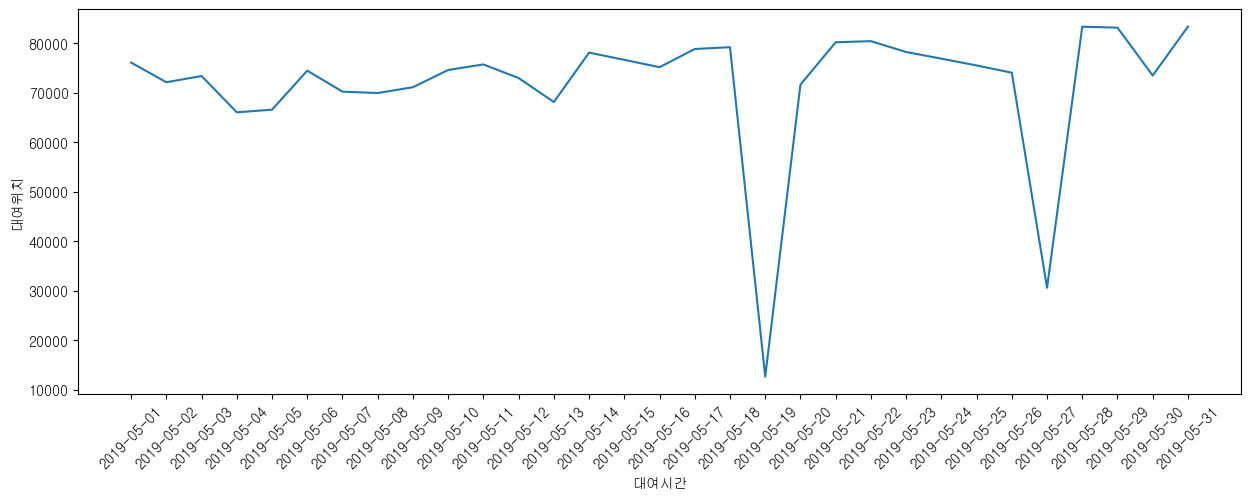

In [50]:
import matplotlib.pyplot as plt
from matplotlib import rc
import seaborn as sns

rc('font', family='gulim')
plt.figure(figsize=(15, 5))

sns.lineplot(data=df2, x=df2.index, y='대여위치')
plt.xticks(df2.index)
plt.xticks(rotation=45)
plt.show()

In [ ]:
# 인덱스에서 2019년 5월 1일 00시 01분에 대여한 건수만 필터
df3 = df1.loc['2019-05-01 00:01']
df3

In [ ]:
flow = pd.crosstab(df3['대여위치'], df3['반납위치'])
flow

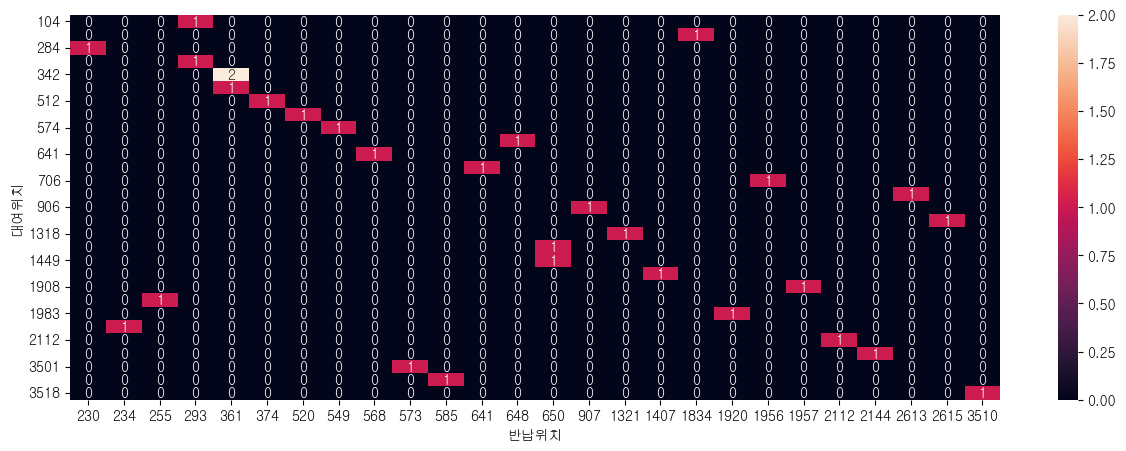

In [54]:
import matplotlib.pyplot as plt
from matplotlib import rc
import seaborn as sns

rc('font', family='gulim')
plt.figure(figsize=(15, 5))
sns.heatmap(data=flow, annot=True)
plt.show()

In [55]:
# 시간대별 정렬
df1 = df1.sort_index()

# 5.1 ~ 5.7일까지 필터
df_week = df1.loc['2019-05-01':'2019-05-07']
df_week

,대여위치,반납시간,반납위치,이용시간,이용시간_초단위,이용시간_분단위,이용시간_시단위
대여시간,,,,,,,
2019-05-01 00:00:00,129,2019-05-01 01:25:56,436,0 days 01:25:56,5156.0,85.933333,0.143222
2019-05-01 00:00:02,837,2019-05-01 00:46:34,2070,0 days 00:46:32,2792.0,46.533333,0.077556
2019-05-01 00:00:04,276,2019-05-01 00:06:33,257,0 days 00:06:29,389.0,6.483333,0.010806
2019-05-01 00:00:07,1321,2019-05-01 00:13:48,1351,0 days 00:13:41,821.0,13.683333,0.022806
2019-05-01 00:00:07,228,2019-05-01 00:12:17,1169,0 days 00:12:10,730.0,12.166667,0.020278
...,...,...,...,...,...,...,...
2019-05-07 23:59:54,147,2019-05-08 01:48:44,147,0 days 01:48:50,6530.0,108.833333,0.181389
2019-05-07 23:59:56,2015,2019-05-08 01:17:43,2015,0 days 01:17:47,4667.0,77.783333,0.129639
2019-05-07 23:59:56,1321,2019-05-08 00:12:42,1351,0 days 00:12:46,766.0,12.766667,0.021278


In [56]:
# 대여위치, 반납위치를 그룹으로 반납 횟수 구하기
df4 = df1.groupby(['대여위치', '반납위치'])[['반납위치']].count()
df4

반납위치
대여위치 반납위치      
3    3        5
     529     11
     1625     3
     1689     3
     3518     2
...         ...
9998 840      7
     1906     2
     2176     1
     2183     1
     9998     2

[238229 rows x 1 columns]

In [57]:
df4.rename(columns={"반납위치":"반납횟수"}, inplace=True)
df4

반납횟수
대여위치 반납위치      
3    3        5
     529     11
     1625     3
     1689     3
     3518     2
...         ...
9998 840      7
     1906     2
     2176     1
     2183     1
     9998     2

[238229 rows x 1 columns]

In [58]:
# 인덱스 초기화
df5 = df4.reset_index()

In [59]:
# 상위 25개의 반납회수
df5.sort_values(by='반납횟수', ascending=False)[:25]

,대여위치,반납위치,반납횟수
64321,502,502,5082
20393,207,207,4914
234087,3515,3515,2499
199493,2219,2219,2220
11715,152,152,1950
190527,2102,2102,1630
190574,2102,2183,1611
197075,2183,2102,1536
183794,2002,2002,1251
80679,590,592,1236


In [60]:
df3.to_pickle('./pkl/20260518_bike_df3.pkl')
df5.to_pickle('./pkl/20260518_bike_df5.pkl')